# 6. Empirical analysis

In this notebook we apply the `epistasia` package to real datasets.
We demonstrate:
1. Loading and validating empirical fitness data.
2. Constructing a `Landscape` object.
3. Computing WH spectra, epistasis amplitude, and variance-by-order statistics.
4. Comparing uncertainty and null bootstraps.
5. Visual inspection of significant orders.


In [5]:
###########################
#         IMPORTS         #
###########################

import os
import sys
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('./style.mplstyle') #include plotsyle

###########################
#         HELPERS         #
###########################

# Simple header function for clean console output
def header(title):
    print("\n" + "=" * len(title))
    print(title)
    print("=" * len(title))

#############################################
#     LOAD BINARY LANDSCAPES DEPENDENCE     #
#############################################

# Include your local path to the library here
base_path = os.path.expanduser("~/epistasia1.0/")
sys.path.insert(1, base_path)

# Import the main package
import epistasia as ep

## 6.1 Reading empirical data: landscape with 10 species

In this tutorial we begin working with **empirical data** obtained from a biological landscape involving **10 different species**. These data contain experimental measurements of the community biomass $F(\mathbf{x})$ across multiple system configurations and will serve as the basis for the analyses developed in the previous tutorials.

The landscape includes all $2^{10} = 1024$ possible binary configurations corresponding to presence/absence patterns of the 10 species. Each configuration is associated with a measured value of $F$ and five different replics $r=1,\dots,R=5.

In [23]:
# --- Read empirical data --------------------
data_path = os.path.join(os.path.expanduser("~/FunEcoLab_IBFG Dropbox/Papers/Genetics_Mateu_2026/Datasets_clean/"), "Complete_landscape_Sabela.csv")

df = pd.read_csv(data_path, index_col=False)

L_raw = ep.Landscape.from_dataframe(df)
#alternatively, you can also do: L_raw = ep.landscape_from_file(data_path)
display(L_raw)

,,C10,C9,C8,C7,C6,C5,C4,C1,C12,C14,rep_1,rep_2,rep_3,rep_4,rep_5
state,Order,,,,,,,,,,,,,,,
0000000000,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000
0000000001,1,0,0,0,0,0,0,0,0,0,1,0.048467,0.038793,0.133346,0.046642,0.144859
0000000010,1,0,0,0,0,0,0,0,0,1,0,0.215349,0.030650,0.212454,0.166285,0.199879
0000000011,2,0,0,0,0,0,0,0,0,1,1,0.162641,0.163804,0.130344,0.141865,0.180170
0000000100,1,0,0,0,0,0,0,0,1,0,0,0.160771,0.154306,0.164416,0.111621,0.099257
0000000101,2,0,0,0,0,0,0,0,1,0,1,0.170876,0.139765,0.253409,0.152870,0.192046
0000000110,2,0,0,0,0,0,0,0,1,1,0,0.171582,0.195181,0.171896,0.115580,0.228525
0000000111,3,0,0,0,0,0,0,0,1,1,1,0.153575,0.170719,0.157193,0.150281,0.170767
0000001000,1,0,0,0,0,0,0,1,0,0,0,0.065712,0.055235,0.120205,0.060541,0.043004


## 6.2. Clean batch effect

Before analysing the empirical landscape, we remove systematic distortions introduced by the measurement batches.  In our noise model, each observed replicate $\tilde{F}_r(\mathbf{x})$ differs from the underlying biological signal $\bar{F}(\mathbf{x})$ by an additive shift $a_r$, a multiplicative scaling $b_r$, and a configuration-specific noise term.  The identifiability constraints introduced previously (centering of $\{a_r\}$ and unit geometric mean of $\{b_r\}$) ensure that these batch parameters can be uniquely estimated.

To clean the batch effects, we fit a hierarchical Bayesian model directly on the observed values

\begin{equation}
    \tilde{F}_r(\mathbf{x}) \sim 
    \mathcal{N}\!\big(\bar{F}(\mathbf{x}) + a_r,\; \sigma^2 (\mathbf{x}) b_r^2\big),
\end{equation}

where $\bar{F}(\mathbf{x})$, $a_r$, $b_r$, and the global noise scale $\sigma^2 (\mathbf{x})$ are inferred jointly from all configurations and replicates. This approach retains the full structure of the data (unlike methods based on standardized residuals), propagates uncertainty to all parameters, and enforces the identifiability constraints internally through the parametrization of $a_r$ and $b_r$.

Once the posterior means $\bar{a}_r$ and $\bar{b}_r$ are obtained, we invert the batch model to estimate the residual stochastic component

\begin{equation}
    \hat{\pi}_r(\mathbf{x}) 
    = 
    \frac{
        \tilde{F}_r(\mathbf{x}) - \bar{F}(\mathbf{x}) - \bar{a}_r
    }{
        \bar{b}_r
    }.
\end{equation}

Finally, a batch-corrected replicate is reconstructed as

\begin{equation}
    F_r^{\mathrm{adj}}(\mathbf{x})
    =
    \bar{F}(\mathbf{x})
    +
    \hat{\pi}_r(\mathbf{x}),
\end{equation}

which removes the additive and multiplicative batch distortions while preserving the biological variability. The resulting corrected landscape can then be used safely for downstream analyses such as epistasis quantification, inference of structure, or comparison across experiments.

In practice, this step is implemented with the command


In [7]:
# Correct Batch effects
L, post = ep.correct_batch_effect(
    L_raw, return_posteriors=True,
    seed=12345678, chains=3, iter_warmup=1000, iter_sampling=1000, link="log",
)
print("Cleaned data")
display(L)
#display(L_batchy)

14:13:25 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

14:13:53 - cmdstanpy - INFO - CmdStan done processing.



Cleaned data


,,C10,C9,C8,C7,C6,C5,C4,C1,C12,C14,rep_1,rep_2,rep_3,rep_4,rep_5
state,Order,,,,,,,,,,,,,,,
0000000000,0,0,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0.000000,0.000000
0000000001,1,0,0,0,0,0,0,0,0,0,1,0.047467,0.037793,0.132346,0.045642,0.143859
0000000010,1,0,0,0,0,0,0,0,0,1,0,0.214349,0.029650,0.211454,0.165285,0.198879
0000000011,2,0,0,0,0,0,0,0,0,1,1,0.161641,0.162804,0.129344,0.140865,0.179170
0000000100,1,0,0,0,0,0,0,0,1,0,0,0.159771,0.153306,0.163416,0.110621,0.098257
0000000101,2,0,0,0,0,0,0,0,1,0,1,0.169876,0.138765,0.252409,0.151870,0.191046
0000000110,2,0,0,0,0,0,0,0,1,1,0,0.170582,0.194181,0.170896,0.114580,0.227525
0000000111,3,0,0,0,0,0,0,0,1,1,1,0.152575,0.169719,0.156193,0.149281,0.169767
0000001000,1,0,0,0,0,0,0,1,0,0,0,0.064712,0.054235,0.119205,0.059541,0.042004


After running the Bayesian correction we can visualise the corrected replicates. 

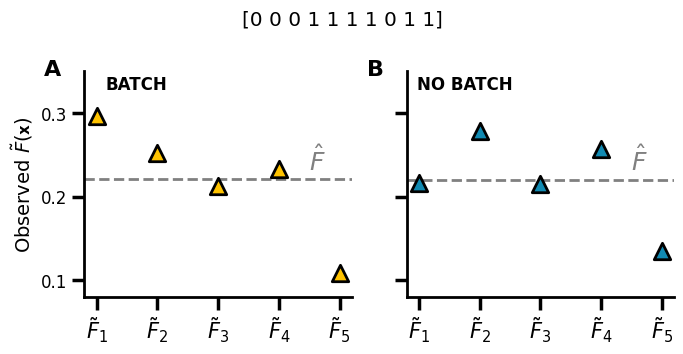

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Choose a specific binary state
x = 123  # modify as needed

vals_raw = L_raw.values[x, :]
vals_adj = L.values[x, :]

colors = ["#ffc300", "#118ab2"]  # with batch / without batch

fig, axes = plt.subplots(1, 2, figsize=(7, 3.6), sharey=True)

# ---------------------------------------------------
# LEFT PANEL — WITH BATCH
# ---------------------------------------------------
ax = axes[0]

# Panel label A
ax.text(
    -0.15, 1.05, "A",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left"
)

# Scatter points
ax.scatter(
    range(1, L_raw.R + 1),
    vals_raw,
    marker="^",
    s=140,
    facecolor=colors[0],
    edgecolor="black",
    linewidth=2,
    zorder=3
)

# Horizontal mean line
mean_raw = vals_raw.mean()
ax.axhline(mean_raw, color="gray", linestyle="--", linewidth=2, zorder=2)
ax.text(
    4.5, mean_raw + 0.005,
    r"$\hat{F}$",
    fontsize=18,
    va="bottom",
    ha="left",
    color="gray"
)

ax.set_ylabel(r"Observed $\tilde{F}(\mathbf{\mathcal{x}})$", fontsize=14)

# Replicate labels rotated 45º
ax.set_xticks(range(1, L_raw.R + 1))
ax.set_xticklabels([f"$\\tilde{{F}}_{{{i}}}$" for i in range(1, L.R + 1)],rotation=0,fontsize=15)

# Ticks every 0.2 on y-axis
ax.yaxis.set_major_locator(MultipleLocator(0.1))

# y-limits
ax.set_ylim(0.1, 0.4)

# Label (BATCH)
ax.text(
    0.08, 0.98,
    "BATCH",
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=12,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ---------------------------------------------------
# RIGHT PANEL — NO BATCH
# ---------------------------------------------------
ax = axes[1]

# Panel label B
ax.text(
    -0.15, 1.05, "B",
    transform=ax.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    ha="left"
)

ax.scatter(
    range(1, L.R + 1),
    vals_adj,
    marker="^",
    s=140,
    facecolor=colors[1],
    edgecolor="black",
    linewidth=2,
    zorder=3
)

mean_adj = vals_adj.mean()
ax.axhline(mean_adj, color="gray", linestyle="--", linewidth=2, zorder=2)
ax.text(
    4.5, mean_adj + 0.005,
    r"$\hat{F}$",
    fontsize=18,
    va="bottom",
    ha="left",
    color="gray"
)

ax.set_xticks(range(1, L.R + 1))
ax.set_xticklabels([f"$\\tilde{{F}}_{{{i}}}$" for i in range(1, L.R + 1)],rotation=0,fontsize=15)

ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylim(0.08, 0.35)

ax.text(
    0.04, 0.98,
    "NO BATCH",
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=12,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# --------------------------------------------------

fig.suptitle(f"{L.states[x]}")

# ---------------------------------------------------
plt.tight_layout()
plt.show()


Each replic  can be seen as point $F_r(\mathbf{x})\in\mathbb{R}^{2^N}$ can be vislualized as box plot. If the model successfully removes the batch effects, the distributions should now align

/tmp/ipykernel_829327/3007212835.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax.boxplot(
/tmp/ipykernel_829327/3007212835.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax.boxplot(


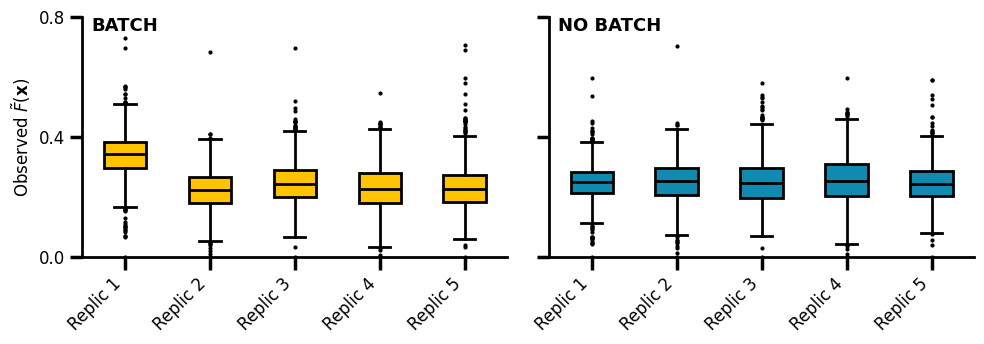

In [9]:
colors = ["#ffc300", "#118ab2"]  # colors for (with batch, without batch)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)

# ---------------------------
# Left: with batch effects
# ---------------------------
ax = axes[0]
vals = L_raw.values

ax.text(
    0.02, 1,            
    "BATCH",        
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=13,
    fontweight="bold"          
)


bp1 = ax.boxplot(
    [vals[:, r] for r in range(L_raw.R)],
    labels=[f"Replic {r+1}" for r in range(L_raw.R)],
    patch_artist=True,
    flierprops=dict(
    marker=".",
    markersize=6,
    markerfacecolor="black",
    markeredgecolor="none",
    markeredgewidth=0
)
)

ax.set_ylim(0,0.8)

ax.yaxis.set_major_locator(MultipleLocator(0.4))

# Color boxes
for patch in bp1["boxes"]:
    patch.set(facecolor=colors[0], alpha=1)
    patch.set(edgecolor="black")   
    patch.set(linewidth=2)

# Style medians
for med in bp1["medians"]:
    med.set(color="black", linewidth=2)

ax.set_ylabel(r"Observed $\tilde{F}(\mathbf{x})$")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Make whiskers and caps thicker
for whisker in bp1["whiskers"]:
    whisker.set(linewidth=2)   
for cap in bp1["caps"]:
    cap.set(linewidth=2)

# ---------------------------
# Right: after correction
# ---------------------------
ax = axes[1]
vals2 = L.values

ax.text(
    0.02, 1,
    "NO BATCH",
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=13,
    fontweight="bold"
)

bp2 = ax.boxplot(
    [vals2[:, r] for r in range(L.R)],
    labels=[f"Replic {r+1}" for r in range(L.R)],
    patch_artist=True,
    flierprops=dict(
    marker=".",
    markersize=6,
    markerfacecolor="black",
    markeredgecolor="none",
    markeredgewidth=0,
)
)

ax.set_ylim(0,0.8)

ax.yaxis.set_major_locator(MultipleLocator(0.4))

# Color boxes
for patch in bp2["boxes"]:
    patch.set(facecolor=colors[1], alpha=1)
    patch.set(edgecolor="black")  
    patch.set(linewidth=2)

for med in bp2["medians"]:
    med.set(color="black", linewidth=2)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# ---------------------------
# Remove top/right spines to match your style
# ---------------------------

for whisker in bp2["whiskers"]:
    whisker.set(linewidth=2)
for cap in bp2["caps"]:
    cap.set(linewidth=2)

# Layout
plt.tight_layout()
plt.show()


Additive effects posteriors

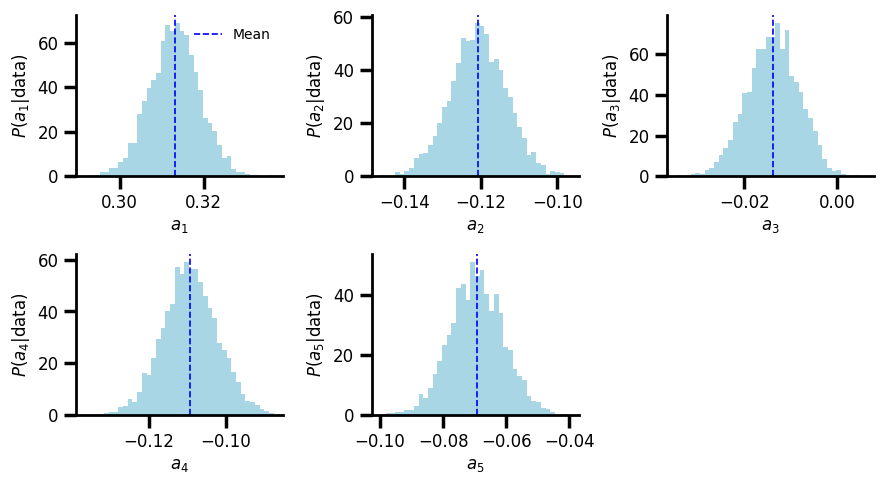

In [10]:
from math import ceil

# Extract posterior draws for a_r
a = np.asarray(post["a"])   # shape: (draws, R)
n_draws, R = a.shape

# Two rows, dynamic number of columns
n_rows = 2
n_cols = ceil(R / n_rows)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.0 * n_cols, 2.5 * n_rows),
)
axes = np.atleast_2d(axes)

# Plot posterior histograms for each a_r
for r in range(R):
    row = r // n_cols
    col = r % n_cols
    ax = axes[row, col]
    ax.hist(a[:, r], bins=40, density=True,color="#a9d6e5")
 
    mean_r = a[:, r].mean()
    ax.axvline(mean_r, color="blue", linestyle="--", linewidth=1.2,label="Mean")
    ax.set_xlabel(rf"$a_{r+1}$")
    ax.set_ylabel(rf"$P(a_{r+1}|\text{{data}})$")

    if(r==0):
        ax.legend(frameon=False,loc="best",fontsize=10)

# Hide unused axes
for idx in range(R, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].axis("off")

fig.tight_layout()
plt.show()


Multiplicative effects posterios

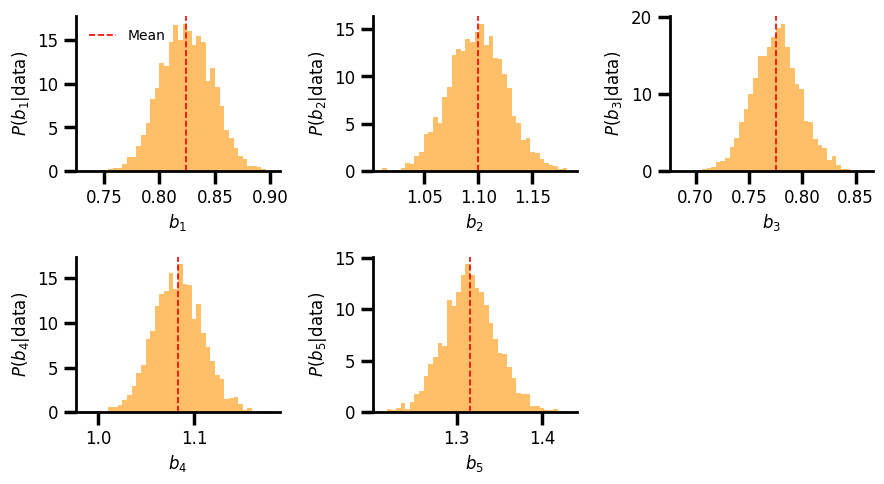

In [11]:
# Extract posterior draws for b_r
b = np.asarray(post["b"])   # shape: (draws, R)
n_draws, R = b.shape

# Two rows, dynamic number of columns
n_rows = 2
n_cols = ceil(R / n_rows)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.0 * n_cols, 2.5 * n_rows),
)
axes = np.atleast_2d(axes)

# Plot posterior histograms for each b_r
for r in range(R):
    row = r // n_cols
    col = r % n_cols
    ax = axes[row, col]

    # Histogram
    ax.hist(b[:, r], bins=40, density=True, color="#ffbf69")

    # Posterior mean line
    mean_r = b[:, r].mean()
    ax.axvline(mean_r, color="red", linestyle="--", linewidth=1.2,label="Mean")

    # Labels
    ax.set_xlabel(rf"$b_{r+1}$")
    ax.set_ylabel(rf"$P(b_{r+1}|\text{{data}})$")

    if(r==0):
        ax.legend(frameon=False,loc="best",fontsize=10)

# Hide unused axes
for idx in range(R, n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].axis("off")

fig.tight_layout()
plt.show()

Hyper-parameters posterios

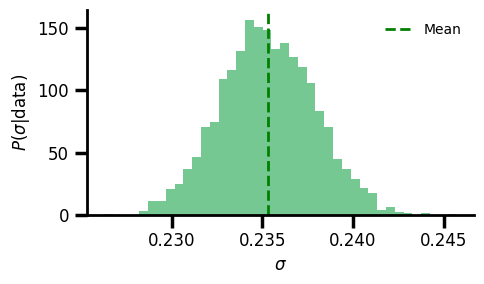

In [12]:
# Extract posterior draws for sigma
sigma = np.asarray(post["sigma"])   # shape: (draws,)

fig, ax = plt.subplots(figsize=(5, 3))

# Histogram
ax.hist(sigma, bins=40, density=True, color="#76c893")

# Vertical posterior mean line
mean_sigma = sigma.mean()
ax.axvline(mean_sigma, color="green", linestyle="--", linewidth=2,label="Mean")

# Axis labels
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$P(\sigma|\text{data})$")

# Legend
ax.legend(frameon=False,loc="best",fontsize=10)

fig.tight_layout()
plt.show()


## 6.3. Epistasis amplitude

The **epistasis amplitude** measures how much each interaction order contributes to the global structure of the functional landscape. For a given order $S$, it is defined as the average squared strength of all $S$-way interactions:

\begin{equation}
\langle E_S^2 \rangle = \binom{N}{S}^{-1} \sum_{|s|=S} E_s^2 .
\end{equation}

It summarizes the **global magnitude** of epistasis at order \(S\): large values indicate that interactions of that order play an important role, while small values indicate weak or negligible contributions. Because it averages over all backgrounds, the amplitude is more stable than individual epistatic coefficients and provides a clean “spectral” view of the map.

The function `epistasis_amplitude()` computes these amplitudes together with bootstrap confidence intervals and a noise-based null model. By comparing the empirical amplitude to the null distribution, we can assess **which interaction orders contain detectable biological signal**.


In [13]:
df_amp = ep.epistasis_amplitude(
    L,
    B_uncertainty=1000,
    B_null=1000,
    ci_level=0.95,
    multipliers="normal",
    as_dataframe=True,
)

display(df_amp)

,Order,Epistasis amplitude <E^2>_k,CI low,CI high,Null CI low,Null CI high,SNR (null),Null mean,Variance (obs),Variance (null median),P-value order,P-value var
0,1,0.000588,0.000537,0.000646,3.639995e-07,0.000009,250.283945,0.000003,0.000588,0.000002,0.000,0.838
1,2,0.000254,0.000236,0.000302,2.028709e-06,0.000033,30.744038,0.000011,0.000254,0.000009,0.000,0.838
2,3,0.000099,0.000116,0.000180,8.241979e-06,0.000133,3.037659,0.000045,0.000099,0.000037,0.064,0.838
3,4,0.000231,0.000317,0.000557,3.182961e-05,0.000506,1.850415,0.000181,0.000231,0.000152,0.255,0.838
4,5,0.000614,0.001024,0.001785,1.290974e-04,0.002070,1.193759,0.000728,0.000614,0.000606,0.490,0.838
5,6,0.001903,0.003604,0.006447,5.262948e-04,0.008166,0.947860,0.002900,0.001903,0.002446,0.632,0.838
6,7,0.006041,0.012245,0.026460,2.178650e-03,0.032100,0.760871,0.011487,0.006041,0.009587,0.744,0.838
7,8,0.014570,0.036690,0.091495,7.664665e-03,0.131104,0.446172,0.046004,0.014570,0.038102,0.890,0.838
8,9,0.093225,0.086407,0.546299,2.243038e-02,0.655096,0.562915,0.190309,0.093225,0.140687,0.694,0.838
9,10,0.056973,0.001160,3.847297,5.581987e-04,4.617312,0.039951,0.750971,0.056973,0.253663,0.737,0.838


The variance spectrum tells us how much of the total functional variation $V_{\text{tot}}$ is explained by additive, pairwise, and higher-order interactions. The **epistasis amplitude**, $\langle \mathcal{E}_S^2 \rangle$, complements this view by measuring the average squared strength of all interactions of order $S$. It captures the *global magnitude* of epistasis at that order, independently of background.

The function `ep.plot_variance_and_amplitude()` jointly visualizes both quantities, together with bootstrap confidence intervals and a noise-based null model, allowing us to assess how interaction strength and functional variance are distributed across orders of epistasis.


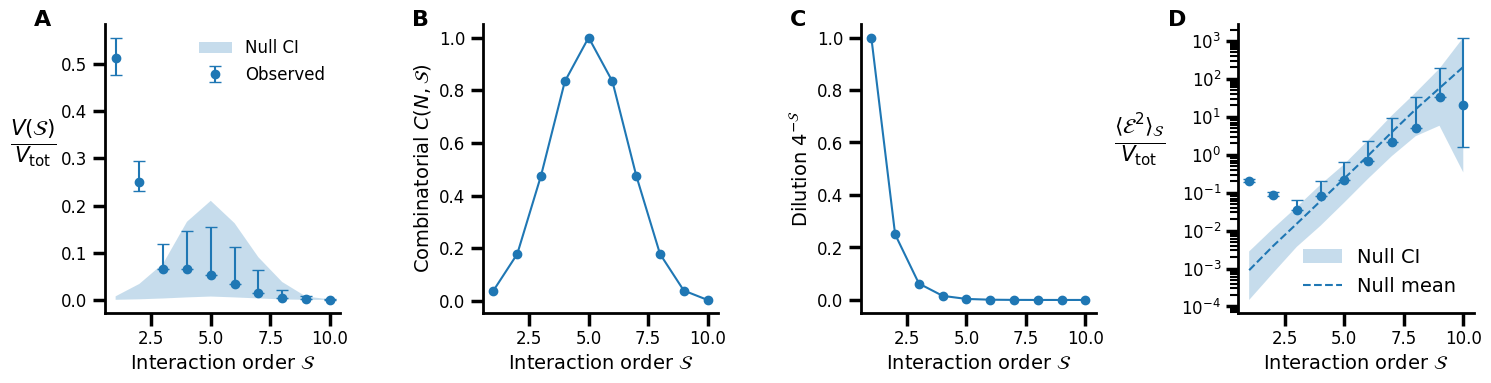

In [14]:
fig, axes, data = ep.plot_variance_and_amplitude(
    L,
    B_uncertainty=100,
    B_null=100,
    as_fraction=True,
    show_components=True,
    rng=np.random.default_rng(125),
    return_data=True,
    figsize=(15, 4),
    ci_method_uncertainty = "percentile"  # {"percentile","studentized","bca"}
)

The score $1 - p_\text{value}$ quantifies how confidently we can reject the null hypothesis of “no interaction” at each order.  Values close to **1** indicate strong evidence that the observed epistasis cannot be explained by noise alone, whereas values near **0** suggest that the interaction magnitude is statistically indistinguishable from the null model. Plotting interaction order vs. $1 - p\_\text{value}$ provides a clear visual summary of **which orders contain detectable biological signal**.


Text(0.5, 0, 'Epistatic order')

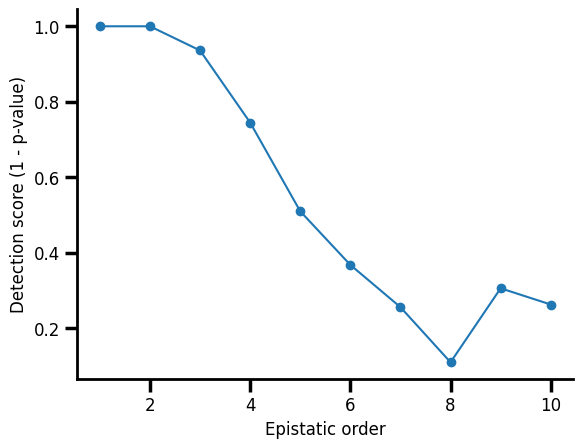

In [15]:
plt.plot(df_amp["Order"],1-df_amp["P-value order"],"o-")
plt.ylabel("Detection score (1 - p-value)")
plt.xlabel("Epistatic order")

## 6.4. Local Epistasis

In [16]:
delta2 = ep.focal_effect(
    L,
    i=2,
    missing_policy="drop",       # tolerates missing states
    nan_policy="omit",           # ignore NaNs inside alternating sum
    B_uncertainty=1000,         # bootstrap draws for uncertainty bands
    B_null=1000,                # bootstrap draws for null test
    multipliers="rademacher",  # type of wild multipliers
    ci_level=0.95,
    as_dataframe=True,          # return as DataFrame
)

display(delta2)

,Background,Background loci,Background loci names,Background active loci,Background active names,Order,Loci involved,Loci names,Epistasis (mean),Experimental SD,...,Prob(Effect > 0),Prob(Effect < 0),Null CI (low),Null CI (high),Signal-to-Null-Noise (SNR),Null variance (per background),Variance (observed),Variance (null median),p-var,p-null
0,000000000,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)",(),(),1,"(2,)","(C8,)",0.194680,NaN,...,1.000,0.000,-0.063592,0.073014,5.412793,0.001294,0.002147,0.001438,0.0,0.000
1,000000001,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(9,)","(C14,)",1,"(2,)","(C8,)",0.177508,NaN,...,1.000,0.000,-0.069482,0.072461,4.686714,0.001434,0.002147,0.001438,0.0,0.003
2,000000010,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(8,)","(C12,)",1,"(2,)","(C8,)",0.057968,NaN,...,0.957,0.043,-0.067554,0.071075,1.632706,0.001261,0.002147,0.001438,0.0,0.095
3,000000011,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(8, 9)","(C12, C14)",1,"(2,)","(C8,)",0.029363,NaN,...,0.958,0.042,-0.066729,0.069098,0.784266,0.001402,0.002147,0.001438,0.0,0.402
4,000000100,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(7,)","(C1,)",1,"(2,)","(C8,)",0.113849,NaN,...,1.000,0.000,-0.071361,0.069934,2.982327,0.001457,0.002147,0.001438,0.0,0.008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,111111011,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(0, 1, 3, 4, 5, 6, 8, 9)","(C10, C9, C7, C6, C5, C4, C12, C14)",1,"(2,)","(C8,)",0.025767,NaN,...,0.684,0.316,-0.077189,0.068034,0.674061,0.001461,0.002147,0.001438,0.0,0.464
508,111111100,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(0, 1, 3, 4, 5, 6, 7)","(C10, C9, C7, C6, C5, C4, C1)",1,"(2,)","(C8,)",0.033614,NaN,...,0.837,0.163,-0.067971,0.075543,0.870311,0.001492,0.002147,0.001438,0.0,0.323
509,111111101,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(0, 1, 3, 4, 5, 6, 7, 9)","(C10, C9, C7, C6, C5, C4, C1, C14)",1,"(2,)","(C8,)",-0.007927,NaN,...,0.416,0.584,-0.068429,0.068738,0.217822,0.001325,0.002147,0.001438,0.0,0.835
510,111111110,"(0, 1, 3, 4, 5, 6, 7, 8, 9)","(C10, C9, C7, C6, C5, C4, C1, C12, C14)","(0, 1, 3, 4, 5, 6, 7, 8)","(C10, C9, C7, C6, C5, C4, C1, C12)",1,"(2,)","(C8,)",0.018088,NaN,...,0.615,0.385,-0.070612,0.073741,0.474629,0.001452,0.002147,0.001438,0.0,0.606


In [17]:
full_df = ep.compute_full_epistasis(
    L,
    min_order=1,
    max_order=L.N,
    B_uncertainty=1000,
    B_null=1000,
)

/home/jose/epistasia1.0/epistasia/epistasis.py:1045: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_obs = float(np.nanvar(mean, ddof=1))                 # scalar
/home/jose/epistasia1.0/epistasia/epistasis.py:1046: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_null_global = np.nanvar(eps_null_b, axis=0, ddof=1)  # (B,)


In [18]:
display(full_df.loc[(full_df["p-null"] < 0.05) & (full_df["Order"] == 1)])

,Interaction type,Background,Background loci,Background loci names,Background active loci,Background active names,Order,Loci involved,Loci names,Epistasis (mean),...,Prob(Effect > 0),Prob(Effect < 0),Null CI (low),Null CI (high),Signal-to-Null-Noise (SNR),Null variance (per background),Variance (observed),Variance (null median),p-var,p-null
119,order-1,001110111,"(1, 2, 3, 4, 5, 6, 7, 8, 9)","(C9, C8, C7, C6, C5, C4, C1, C12, C14)","(3, 4, 5, 7, 8, 9)","(C7, C6, C5, C1, C12, C14)",1,"(0,)","(C10,)",-0.099070,...,0.085,0.915,-0.074749,0.070847,2.579310,0.001475,0.001972,0.001437,0.001,0.018
126,order-1,001111110,"(1, 2, 3, 4, 5, 6, 7, 8, 9)","(C9, C8, C7, C6, C5, C4, C1, C12, C14)","(3, 4, 5, 6, 7, 8)","(C7, C6, C5, C4, C1, C12)",1,"(0,)","(C10,)",0.075802,...,0.980,0.020,-0.071907,0.069755,2.029869,0.001395,0.001972,0.001437,0.001,0.036
176,order-1,010110000,"(1, 2, 3, 4, 5, 6, 7, 8, 9)","(C9, C8, C7, C6, C5, C4, C1, C12, C14)","(2, 4, 5)","(C8, C6, C5)",1,"(0,)","(C10,)",-0.201185,...,0.158,0.842,-0.069469,0.067901,5.229824,0.001480,0.001972,0.001437,0.001,0.001
180,order-1,010110100,"(1, 2, 3, 4, 5, 6, 7, 8, 9)","(C9, C8, C7, C6, C5, C4, C1, C12, C14)","(2, 4, 5, 7)","(C8, C6, C5, C1)",1,"(0,)","(C10,)",-0.119612,...,0.224,0.776,-0.074406,0.076605,3.061824,0.001526,0.001972,0.001437,0.001,0.010
231,order-1,011100111,"(1, 2, 3, 4, 5, 6, 7, 8, 9)","(C9, C8, C7, C6, C5, C4, C1, C12, C14)","(2, 3, 4, 7, 8, 9)","(C8, C7, C6, C1, C12, C14)",1,"(0,)","(C10,)",-0.079076,...,0.146,0.854,-0.078130,0.066538,2.114148,0.001399,0.001972,0.001437,0.001,0.037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5081,order-1,111011001,"(0, 1, 2, 3, 4, 5, 6, 7, 8)","(C10, C9, C8, C7, C6, C5, C4, C1, C12)","(0, 1, 2, 4, 5, 8)","(C10, C9, C8, C6, C5, C12)",1,"(9,)","(C14,)",-0.073547,...,0.054,0.946,-0.073972,0.067800,2.051818,0.001285,0.001690,0.001434,0.055,0.042
5086,order-1,111011110,"(0, 1, 2, 3, 4, 5, 6, 7, 8)","(C10, C9, C8, C7, C6, C5, C4, C1, C12)","(0, 1, 2, 4, 5, 6, 7)","(C10, C9, C8, C6, C5, C4, C1)",1,"(9,)","(C14,)",-0.087174,...,0.000,1.000,-0.071793,0.063890,2.438360,0.001278,0.001690,0.001434,0.055,0.016
5106,order-1,111110010,"(0, 1, 2, 3, 4, 5, 6, 7, 8)","(C10, C9, C8, C7, C6, C5, C4, C1, C12)","(0, 1, 2, 3, 4, 7)","(C10, C9, C8, C7, C6, C1)",1,"(9,)","(C14,)",0.077175,...,0.914,0.086,-0.064564,0.068557,2.145322,0.001294,0.001690,0.001434,0.055,0.026
5115,order-1,111111011,"(0, 1, 2, 3, 4, 5, 6, 7, 8)","(C10, C9, C8, C7, C6, C5, C4, C1, C12)","(0, 1, 2, 3, 4, 5, 7, 8)","(C10, C9, C8, C7, C6, C5, C1, C12)",1,"(9,)","(C14,)",-0.086298,...,0.018,0.982,-0.068968,0.072935,2.212500,0.001521,0.001690,0.001434,0.055,0.024


## 6.5. Filter significant epistatic interactions



,i,j,weight,metric,Locus i name,Locus j name
0,0,1,0.149861,mean_abs_epistasis,C10,C9
1,0,2,0.155850,mean_abs_epistasis,C10,C8
2,0,3,0.155220,mean_abs_epistasis,C10,C7
3,0,4,0.143409,mean_abs_epistasis,C10,C6
4,0,5,0.132967,mean_abs_epistasis,C10,C5


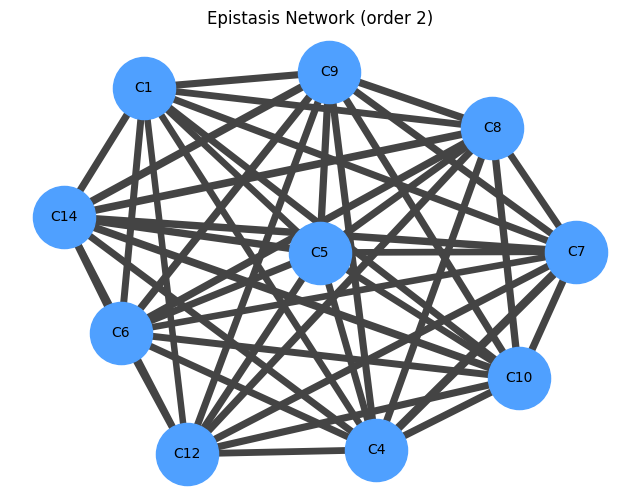

In [19]:
df_sig = ep.filter_significant_interactions(
    full_df,
    min_snr_null=2.0,
    max_p_value_var=None,
    min_prob_sign=0.0,
    max_p_null=0.05,
    # Only order 2 interactions 
    min_order=2,
    max_order=2,
    min_feature_overlap=2,
    feature_col="Loci names",
    p_col_for_filter="p-null",
)

edges_df = ep.epistasis_to_network(
    df_sig,
    order=2,
    agg="mean_abs",              
    feature_names=L.feature_names 
)

display(edges_df.head())

ep.plot_epistasis_network(
    edges_df,
    use_names=True,  
    node_size=2000,
    font_size=10,
)

## 6.6. Volcano plot

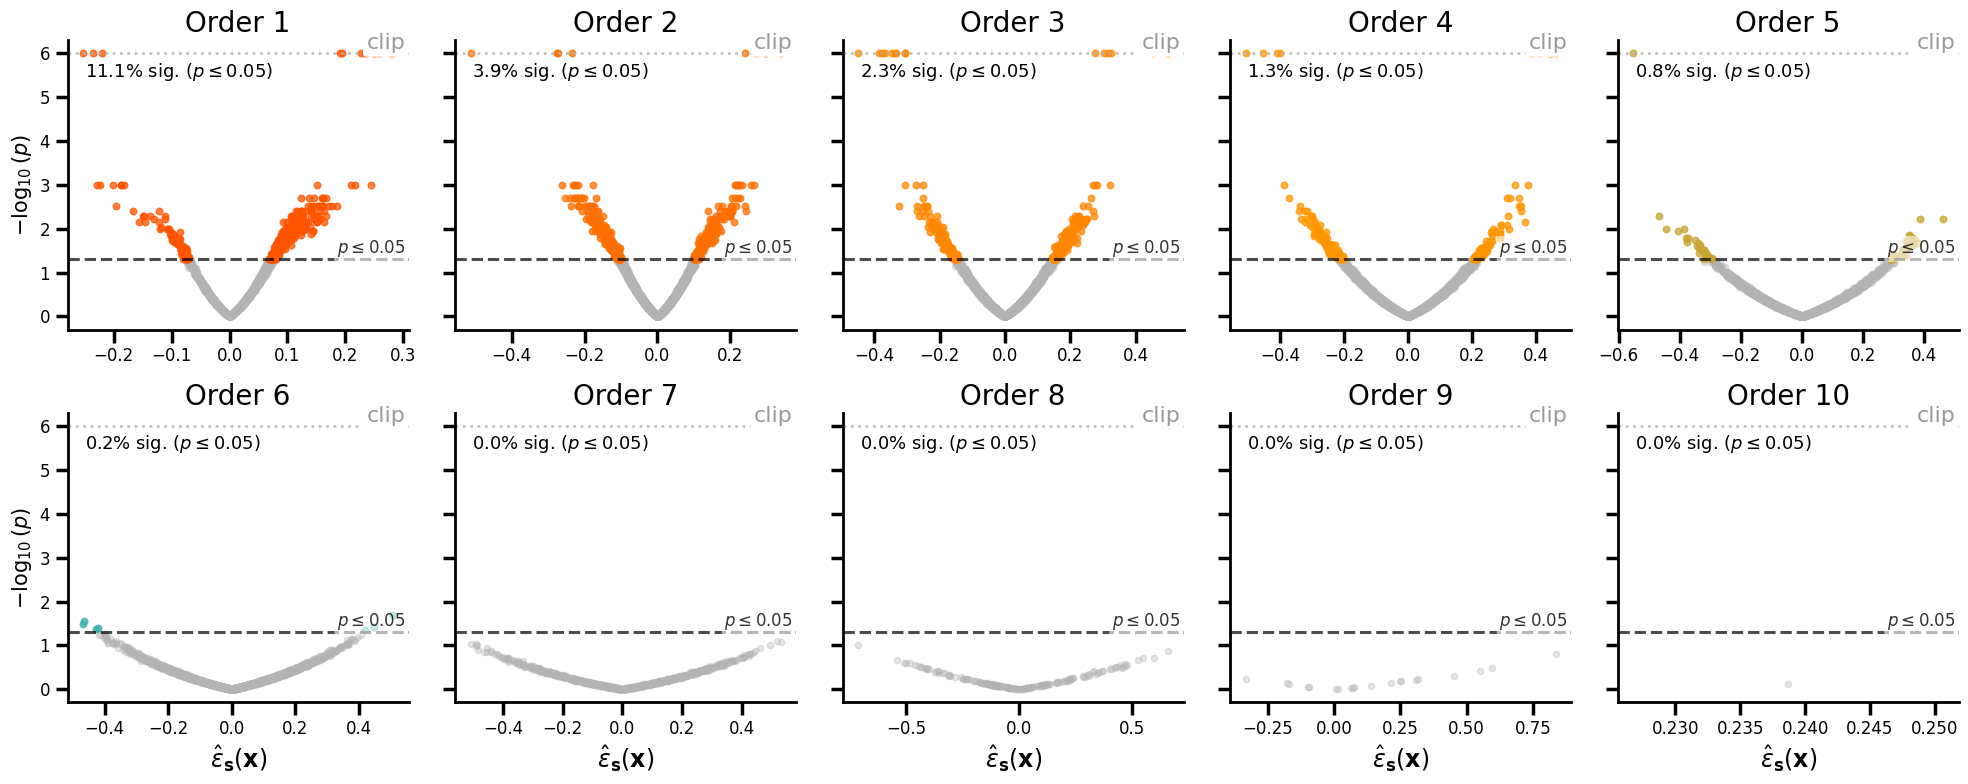

In [20]:
# One panel per order, with significance threshold and % significant annotated
ep.plot_epistasis_volcano(
    full_df,
    orders=[1,2,3,4,5,6,7,8,9,10],
    mode="by-order",
    alpha=0.05,
    clip=1e-6,
    colormap="custom",
)